In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


(-1.375, 1.375, -1.6, 0.6)

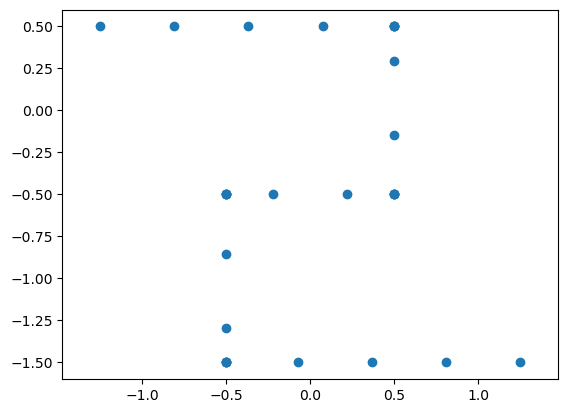

In [2]:
def init_trajectory(sofa_w, sofa_h, control_point_num, middle_rotation=-0.5 * np.pi):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [-sofa_w / 2, 0.5, 0],
        [0.5, 0.5, 0],
        [0.5, 0.5, middle_rotation],
        [0.5, -0.5, middle_rotation],
        [0.5, -0.5, middle_rotation * 2],
        [-0.5, -0.5, middle_rotation * 2],
        [-0.5, -0.5, middle_rotation],
        [-0.5, -1.5, middle_rotation],
        [-0.5, -1.5, 0],
        [sofa_w / 2, -1.5, 0]
    ], control_point_num).T
    return xs, ys, rotations

sofa_w = 2.5   # 求解域的尺寸
sofa_h = 1.0   # 求解域的尺寸

xs, ys, rotations = init_trajectory(  # 初始轨迹
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    control_point_num=30,  # 轨迹的控制点数量
)

plt.scatter(xs, ys)
plt.axis('equal')

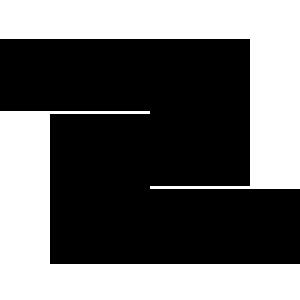

In [ ]:
from utils import test_forbidden_function

@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    return y2 < -2 or y2 > 1 or (x2 > 1 and y2 > -1) or (x2 < -1 and y2 < 0) or (x2 < 0 and y1 * y2 < 0) or (x2 > 0 and (y1 - -1.) * (y2 - -1.) < 0)

image = test_forbidden_function(is_forbidden, -1.5, 1.5, -2.5, 1.5, 300, wall_normal=[0, 0.05])
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [7]:
xs, ys, rotations = np.load('../trajectory/连续两个180°拐角/sofa_590.npy')

Initial survivors: 1.6186046600341797
iter 500 / 20000, maximal_area=1.6186463832855225
iter 1000 / 20000, maximal_area=1.61865234375
iter 1500 / 20000, maximal_area=1.6186643838882446
iter 2000 / 20000, maximal_area=1.6186882257461548
iter 2500 / 20000, maximal_area=1.61872398853302
iter 3000 / 20000, maximal_area=1.61872398853302
iter 3500 / 20000, maximal_area=1.6187299489974976
iter 4000 / 20000, maximal_area=1.618735909461975
iter 4500 / 20000, maximal_area=1.6187478303909302
iter 5000 / 20000, maximal_area=1.6187478303909302
iter 5500 / 20000, maximal_area=1.6187478303909302
iter 6000 / 20000, maximal_area=1.6187478303909302
iter 6500 / 20000, maximal_area=1.6187537908554077
iter 7000 / 20000, maximal_area=1.6187537908554077
iter 7500 / 20000, maximal_area=1.6187777519226074
iter 8000 / 20000, maximal_area=1.6187777519226074
iter 8500 / 20000, maximal_area=1.6187777519226074
iter 9000 / 20000, maximal_area=1.6187777519226074
iter 9500 / 20000, maximal_area=1.6187777519226074
iter

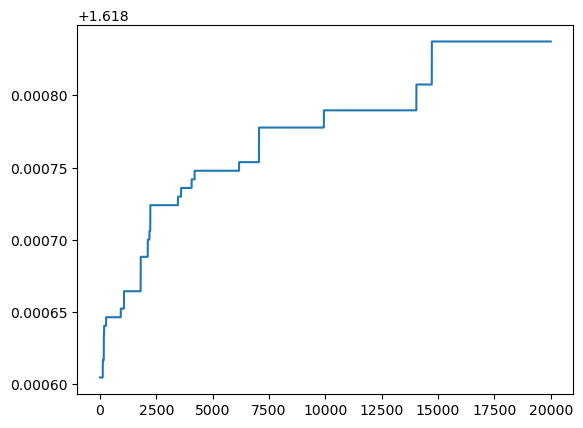

In [8]:
best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.02,  # 变异率
    mutation_sigma_rotation = 0.004,  # 变异率
    iterations = 20000,  # 200000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=83,
    save_image_path='../images/连续两个180°拐角/sofa_',
    save_image_start_id=590,
    save_trajectory_path='../trajectory/连续两个180°拐角/sofa_'
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)